<a href="https://colab.research.google.com/github/gouri25m-cpu/Machinelearning-Projects/blob/main/churn/telcoCustomer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/sample_data/archive (29).zip')
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [ ]:
df.tail()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
99995,99996,31,Male,49,26.07,Month-to-month,Electronic check,1220.50,No
99996,99997,64,Female,44,123.22,Month-to-month,Mailed check,5384.38,No
99997,99998,48,Other,32,75.37,Month-to-month,Credit card,2372.33,Yes
99998,99999,42,Female,60,114.00,Month-to-month,Mailed check,6826.55,No
99999,100000,72,Male,57,66.76,One year,Credit card,3828.60,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
Contract,0
PaymentMethod,0
TotalCharges,0
Churn,0


<Axes: >

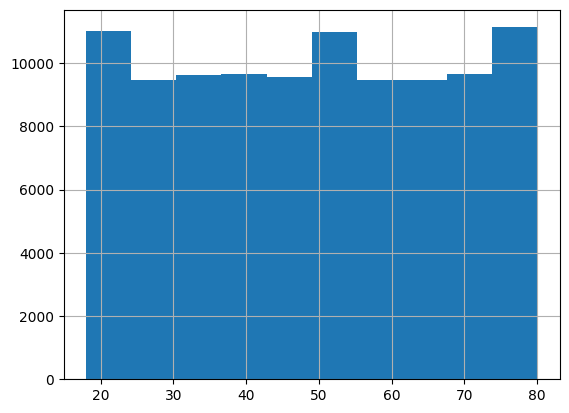

In [ ]:
df["Age"].hist()

In [ ]:
print(df['Contract'].unique())

['Two year' 'Month-to-month' 'One year']


In [ ]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,54915
One year,25261
Two year,19824


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(100000, 9)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(100000, 9)

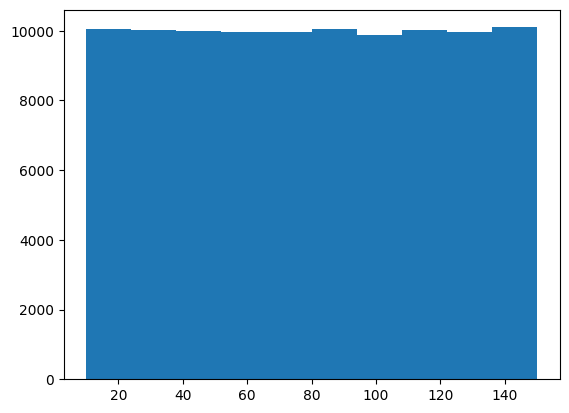

In [ ]:
plt.hist(df["MonthlyCharges"])
plt.show()

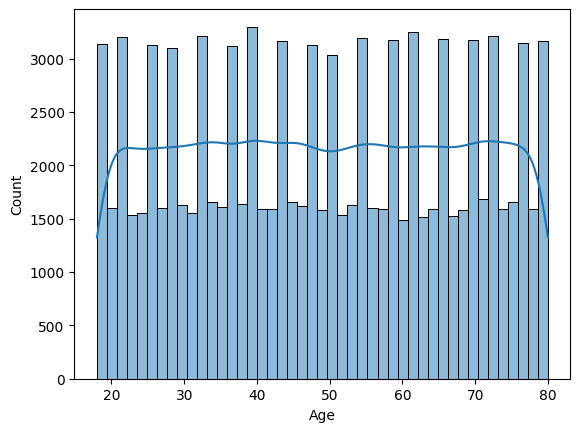

In [ ]:
sns.histplot(df['Age'],kde=True)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df['Contract']=le.fit_transform(df['Contract'])
df['PaymentMethod']=le.fit_transform(df['PaymentMethod'])
df['Churn']=le.fit_transform(df['Churn'])

In [ ]:
dummies=pd.get_dummies(df["Gender"]).astype(int)
dummies

,0,1,2
0,1,0,0
1,0,1,0
2,1,0,0
3,0,1,0
4,1,0,0
...,...,...,...
99995,0,1,0
99996,1,0,0
99997,0,0,1
99998,1,0,0


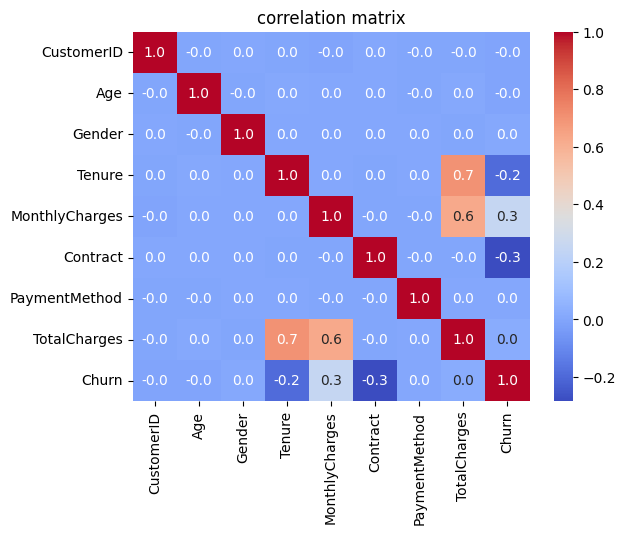

In [ ]:
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

<Axes: >

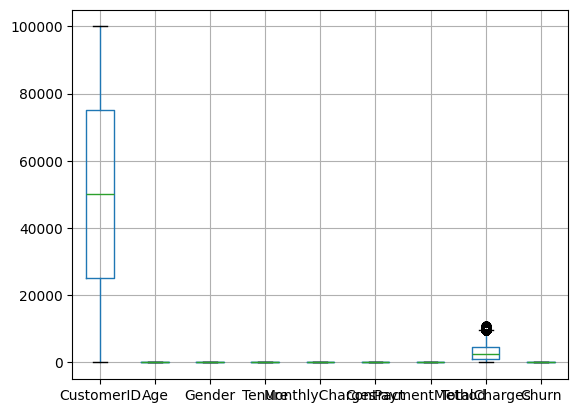

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
      continue
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    df=df[(df[col]>=lower_bound)&(df[col]<=upper_bound)]
  return df
df_cleaned=remove_outliers_iqr(df,exclude_column='Churn')
df=df_cleaned

In [ ]:
df.shape

(99159, 9)

In [ ]:
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
1,2,69,1,32,22.54,0,3,686.78,0
2,3,46,0,10,52.47,1,2,537.88,0
3,4,32,1,22,109.67,0,3,2390.04,1
4,5,60,0,54,130.98,0,1,7081.28,0
5,6,25,0,29,111.55,0,1,3167.13,1
...,...,...,...,...,...,...,...,...,...
99995,99996,31,1,49,26.07,0,2,1220.50,0
99996,99997,64,0,44,123.22,0,3,5384.38,0
99997,99998,48,2,32,75.37,0,1,2372.33,1
99998,99999,42,0,60,114.00,0,3,6826.55,0


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
features=['CustomerID','Age','Gender','Tenure','MonthlyCharges','Contract','PaymentMethod','TotalCharges']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[['CustomerID','Age','Gender','Tenure','MonthlyCharges','Contract','PaymentMethod','TotalCharges']]
y=df['Churn']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Baseline model accuracy:{accuracy:.2f}')

Baseline model accuracy:0.73


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
